In [1]:
# python libs
import glob
import os

# data libs
import pandas as pd
import torch

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

from IPython.display import display, clear_output

from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.manifold import TSNE
import matplotlib as mpl

In [4]:
from Bio.Seq import Seq
from Bio import SeqIO

In [5]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Outline

Applying the ESM2-based model to Nick and Matt's isolated bacteria + Topt data for external validation of the methods

# Arthobacter

## Step 1. annotate genomes
From `/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Arthrobacter/genomes`  
`ls *.fasta > genome_list.txt`  
`~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm`  
`python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./`  
`cat ./genomes/*_adk.faa > adks.faa`  
` mafft --keeplength --add adks.faa ./../../20240122_all_adks_filtered.afa > keeplength_adk.afa`  
`clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa`  

In [6]:
with open('./../data/20240122_all_adks_filtered_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

aln_df = pd.concat(lines, axis=1).T

aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,-,M,-,N,I,I,L,L,G,P,...,L,D,N,-,-,-,-,-,-,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,M,M,-,G,I,V,M,L,G,A,...,L,L,-,-,-,-,-,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,-,M,-,R,L,I,L,L,G,A,...,L,G,-,-,-,R,-,-,-,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,-,M,-,R,L,L,I,M,G,P,...,L,T,K,-,-,-,-,-,-,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,G,-,-,A,I,L,I,L,G,A,...,L,E,Y,-,L,L,E,K,-,-


In [7]:
with open('./../data/validation_datasets/Arthrobacter/keeplength_adk_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

arth_aln_df = pd.concat(lines, axis=1).T

arth_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,-,M,-,N,I,I,L,L,G,P,...,L,D,N,-,-,-,-,-,-,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,M,M,-,G,I,V,M,L,G,A,...,L,L,-,-,-,-,-,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,-,M,-,R,L,I,L,L,G,A,...,L,G,-,-,-,R,-,-,-,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,-,M,-,R,L,L,I,M,G,P,...,L,T,K,-,-,-,-,-,-,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,G,-,-,A,I,L,I,L,G,A,...,L,E,Y,-,L,L,E,K,-,-


In [14]:
# check that the original alignment was maintained
(arth_aln_df.iloc[:5, :] == aln_df.iloc[:5, :]).sum().value_counts()

5    237
Name: count, dtype: int64

## Embedding isolate adks

### Functions and imports

In [15]:
from esm import pretrained
from esm.data import BatchConverter

In [438]:
from esm import pretrained
from esm.data import BatchConverter
import torch

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.manifold import TSNE

In [22]:
def get_residue_loc(row, col, base=0):
    '''
    given an aligned protein (with gaps) as Series
    get the residue number of the requested column in the protein
    (i.e. the original index of the residue)
    '''
    
    # make sure it's not a gap
    if row.loc[col] == '-':
        raise KeyError('Desired col is a gap in this sequence')

    # base must be zero or one
    assert base in [0, 1]
    
    loc = row.index.get_loc(col)
    row_slice = row.iloc[:loc+1]
    _str = ''.join(row_slice[row_slice.eq('-')].astype(str))
    
    return len(_str) + base

In [16]:
# Load model and alphabet
model, alphabet = pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

ESM2(
  (embed_tokens): Embedding(33, 320, padding_idx=1)
  (layers): ModuleList(
    (0-5): 6 x TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=320, out_features=320, bias=True)
        (v_proj): Linear(in_features=320, out_features=320, bias=True)
        (q_proj): Linear(in_features=320, out_features=320, bias=True)
        (out_proj): Linear(in_features=320, out_features=320, bias=True)
        (rot_emb): RotaryEmbedding()
      )
      (self_attn_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=320, out_features=1280, bias=True)
      (fc2): Linear(in_features=1280, out_features=320, bias=True)
      (final_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
  )
  (contact_head): ContactPredictionHead(
    (regression): Linear(in_features=120, out_features=1, bias=True)
    (activation): Sigmoid()
  )
  (emb_layer_norm_after): LayerNorm((320,), eps=1e-05, elementwis

## Arthrobacter

In [18]:
arth_aln_df = arth_aln_df[~arth_aln_df.index.isin(aln_df.index)]

In [19]:
data = []
# for each protein
for index, row in arth_aln_df.iterrows():
    seq = ''.join([s for s in row.values if s != '-'])

    # Clean sequence to ensure valid AAs only
    VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
    clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
    
    if len(seq) == len(clean_seq):
        # Batch convert
        data.append((index, clean_seq))
    else:
        print('Uh oh, invalid AA!')
        
    # print(len(protein.sequence), len(seq), protein.get_embedding(layer=12).shape)

In [20]:
%%time
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
# per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 14.9 s, sys: 5.47 s, total: 20.4 s
Wall time: 1.38 s


In [25]:
arth_aln_df

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
contig_4_579|8HZ65L_1_ASP410-2_hmmsearch.tbl|XXXtemp=XXX|bitscore=175.9,M,-,-,R,L,L,I,I,G,P,...,L,E,-,-,-,S,D,A,S,-
contig_2_682|8HZ65L_3_24664_hmmsearch.tbl|XXXtemp=XXX|bitscore=170.5,M,-,-,R,M,L,I,I,G,P,...,I,-,-,-,-,E,A,A,K,A
contig_1_351|barcode01_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=176.1,M,-,-,R,L,L,I,I,G,P,...,L,E,-,-,-,G,D,A,S,-
contig_1_2021|barcode02_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=176.7,M,-,-,R,L,L,I,I,G,P,...,L,E,-,-,-,A,N,A,S,-
contig_1_919|barcode03_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=168.9,M,-,-,R,M,L,I,I,G,P,...,I,-,-,-,-,K,A,A,Q,T
contig_1_578|barcode04_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.8,M,-,-,R,M,L,I,I,G,P,...,I,-,-,-,-,E,S,A,K,A
contig_1_1185|barcode05_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=174.3,M,-,-,R,M,L,I,I,G,P,...,I,-,-,-,-,K,A,A,Q,A
contig_1_1022|barcode06_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.1,M,-,-,R,M,L,I,I,G,P,...,I,-,-,-,-,K,A,A,Q,A
contig_1_2101|barcode07_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.1,M,-,-,R,M,L,I,I,G,P,...,I,-,-,-,-,K,A,A,Q,A
contig_1_765|barcode08_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=175.9,M,-,-,R,L,L,I,I,G,P,...,L,E,-,-,-,G,N,A,S,-


In [29]:
col_datasets = {}
# for each column in the alignment
for col in arth_aln_df.columns:
    # get proteins which have a residue (not a gap) at this col
    rows = arth_aln_df[~arth_aln_df[col].eq('-')].index
    col_str = f'{len(rows)} rows available for col {col}'

    # get the rows
    subset = arth_aln_df.loc[rows, :]
    # get which residue this corresponds to in each protein, zero-indexed
    indeces = subset.apply(lambda row: get_residue_loc(row, col=col, base=0), axis=1)

    if len(indeces) > 0:
        # for each protein
        temp_list = []
        for j, (index, item) in enumerate(indeces.items()):
            
            # progress bar
            if j % 100 == 0:
                progress_str = '#' * int((j / len(indeces)) * 20)
                fill_str = '-' * (20-len(progress_str))
                print(col_str + f' |{progress_str}{fill_str}|     ', end='\r')
    
            # get the embedding for that site in that protein
            ploc_in_reps = labels.index(index)
            tensor = pd.Series(data=reps.detach()[ploc_in_reps, item+1, :].numpy(), name=index)
            temp_list.append(tensor)
            
        col_datasets[col] = pd.concat(temp_list, axis=1)

In [31]:
col_datasets.keys()

dict_keys([0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 193, 194, 195, 196, 199, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 224, 226, 227, 228, 232, 233, 234, 235, 236])

In [33]:
arth_md = pd.read_csv('./../data/validation_datasets/Arthrobacter/md/2025_07_15-TOPT_Genomes.csv')
arth_md.head()

,Group,Group2,Subproject,sample,EXP,Topt,Genome_ID
0,Antarctica,Antarctic Isolate,Antarctica,70B,EXP10B,16,barcode29_consensus.fasta
1,Antarctica,Antarctic Isolate,Antarctica,ASP_172-3(173-2),EXP10B,17,barcode36_consensus.fasta
2,Antarctica,Antarctic Isolate,Antarctica,ASP_190-3,EXP13,18,barcode03_consensus.fasta
3,Antarctica,Antarctic Isolate,Antarctica,ASP_192-5,EXP6,16,barcode38_consensus.fasta
4,Antarctica,Antarctic Isolate,Antarctica,ASP_29-2,EXP13,17,barcode48_consensus.fasta


## ensemble predictions from main model for arthrobacter species

here we go!!!!

In [34]:
with open('./../data/proclam/esm2_t6_8M_UR50D/models.pickle', 'rb') as handle:
    models = pickle.load(handle)

In [294]:
y = arth_md.assign(id=arth_md['Genome_ID'].apply(lambda x: x.split('.fasta')[0])).set_index('id')['Topt']

In [373]:
high_frac_sites = (~arth_aln_df.eq('-')).sum() / arth_aln_df.shape[0]
high_frac_sites[high_frac_sites < 0.25]

1      0.964706
3      0.992312
4      0.998369
5      0.998952
6      0.999418
         ...   
219    0.999534
220    0.999068
221    0.999185
224    0.998486
227    0.998952
Length: 170, dtype: float64

Text(0.5, 1.0, 'Arthrobacter')

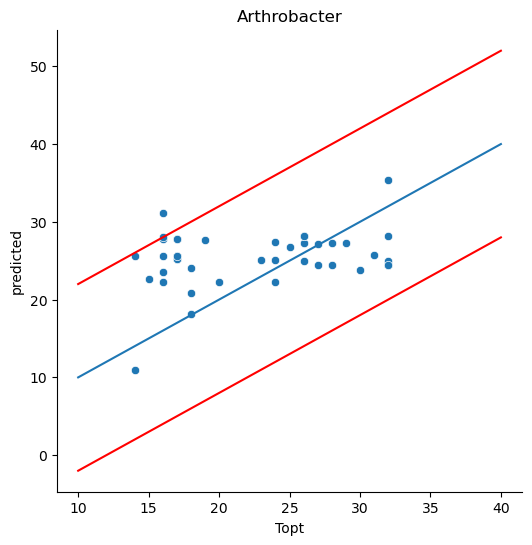

In [377]:
predictions = []
for col in list(col_datasets.keys()):
    if col in high_frac_sites[high_frac_sites < 0.5].index:
        predictions.append(pd.Series(index=col_datasets[col].T.index, data=models[col].predict(col_datasets[col].T), name=col))

y_pred = pd.concat(predictions, axis=1) 
y_pred.index = [s.split('|')[1].split('_hmm')[0] for s in y_pred.index]
y_mean = y_pred.mean(1).rename('predicted')
plotdf = pd.merge(y_mean, 
         y, 
         left_index=True, right_index=True)

fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=plotdf, y='predicted', x='Topt')

_x, _y = 10, 40
rmse = 12
plt.plot((_x, _y), (_x-rmse, _y-rmse), color='r')
plt.plot((_x, _y), (_x+rmse, _y+rmse), color='r')
plt.plot((_x, _y), (_x, _y))

sns.despine()

ax.set_title('Arthrobacter')

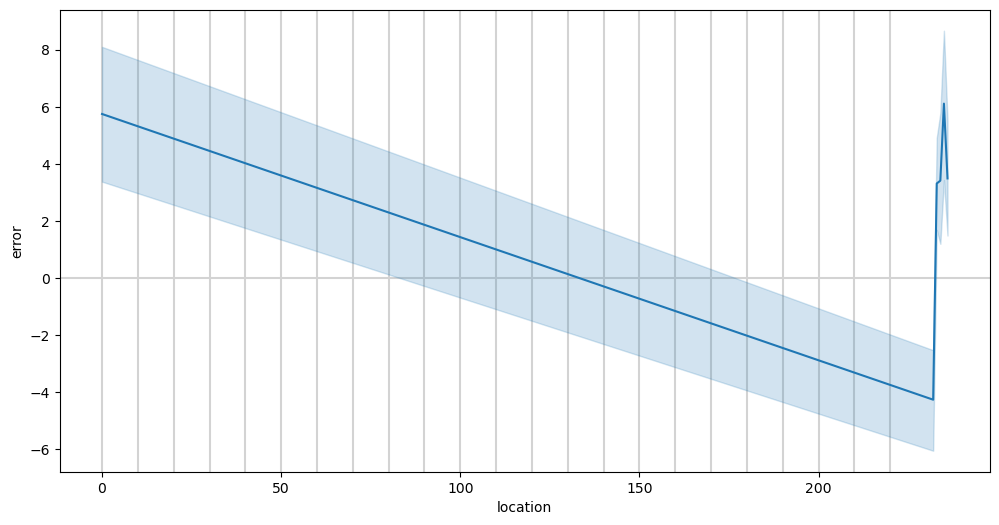

In [378]:
plotdf = y_pred.apply(lambda x: x - y, axis=0).stack().reset_index().rename(columns={'level_0':'genome', 'level_1':'location', 0:'error'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plotdf, 
             x='location', 
             y='error', 
             # hue='genome', 
             legend=False)

for i in range(0, 230, 10):
    ax.axvline(i, color='lightgray', zorder=0)
    
ax.axhline(0, color='lightgray', zorder=0)

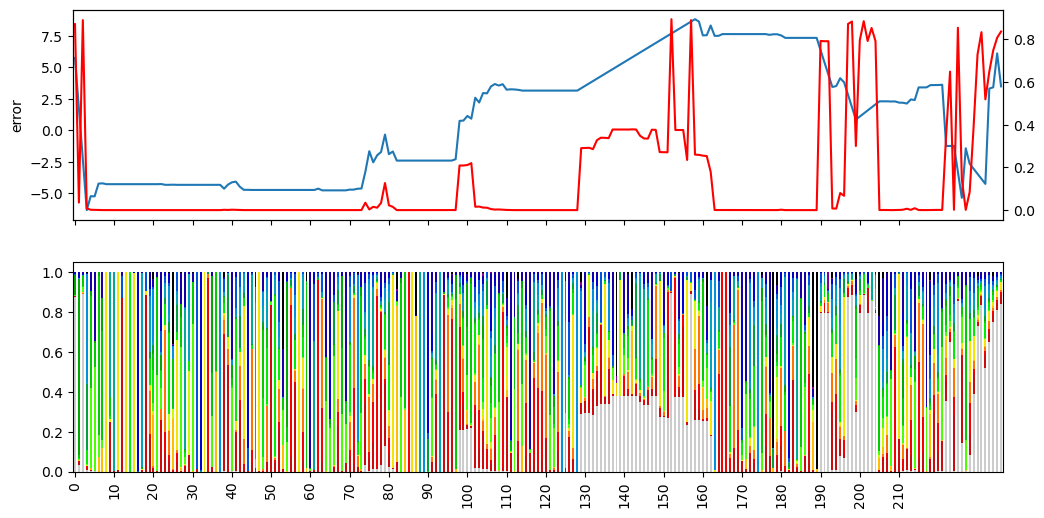

In [367]:
# number of gaps per site
fig= plt.figure(figsize=(12,6))
ax = fig.add_subplot(2,1,1)
sns.lineplot(plotdf.groupby('location').agg({'error':'mean'})['error'], 
             ax=ax)

rax = ax.twinx()
sns.lineplot(arth_aln_df.eq('-').sum() / arth_aln_df.shape[0], ax=rax, color='r')

rax.set_xlim(10, 210)

ax = fig.add_subplot(2,1,2, sharex=ax)
counts.plot(kind='bar', stacked=True, legend=False, ax=ax, cmap='nipy_spectral_r')
ax.set_xticks(range(0,220,10))

In [324]:
col = 0
contributions = []
for item in range(30):
    clear_output(wait=True)
    try:
        thresh = y.loc[col_datasets[col].T.iloc[item, :].name.split('|')[1].split('_hmm')[0]] + 1
        feature_means = train_data[col].loc[[s  for s in train_data[col].index if float(s.split('|')[3].split('temp=')[-1])  < thresh], :].mean()
        coefs = pd.Series(models[col].coef_, index=train_data[col].columns)
        
        # Expected prediction at average values
        expected_pred = feature_means @ coefs + models[col].intercept_
        
        # Prediction for this input
        actual_pred = col_datasets[col].T.iloc[item, :] @ coefs + models[col].intercept_
        
        contribution_df = (col_datasets[col].T.iloc[item, :] - feature_means) * coefs
        
        # fig, ax = plt.subplots(figsize=(12, 4))
        # contribution_df.plot.bar()
        
        contributions.append(contribution_df)
        
        print('diff', contribution_df.sum())
        
        print('expected', expected_pred)
        
        print('actual', actual_pred)
    except KeyError:
        ''

diff 14.460205
expected 12.580078
actual 27.03711


<Axes: >

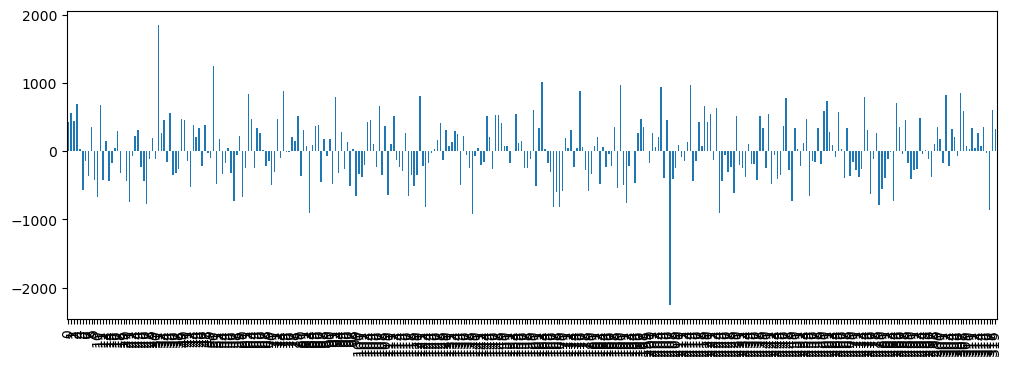

In [325]:
fig, ax = plt.subplots(figsize=(12, 4))
pd.concat(contributions, axis=1).mean(1)
contributions[-1].plot.bar()


In [360]:
counts = arth_aln_df.apply(lambda col: col.value_counts(), axis=0).fillna(0)

counts = counts.divide(counts.sum()).T
counts.head()

,-,A,C,D,E,F,G,H,I,K,...,N,P,Q,R,S,T,V,W,X,Y
0,0.870938,0.007222,0.000116,0.000233,0.000116,0.000582,0.001165,0.000233,0.000466,0.002097,...,0.000466,0.000349,0.000699,0.000466,0.003727,0.011066,0.000466,0.000000,0.0,0.000233
1,0.035294,0.019569,0.000000,0.000466,0.000233,0.001048,0.000116,0.000000,0.008270,0.004426,...,0.000582,0.001398,0.000815,0.003727,0.001980,0.023296,0.007338,0.000000,0.0,0.000233
2,0.889691,0.000699,0.000000,0.000116,0.000349,0.006290,0.001747,0.000233,0.025859,0.005242,...,0.000582,0.001398,0.000116,0.000699,0.000349,0.010949,0.003727,0.000000,0.0,0.002679
3,0.007688,0.003145,0.000000,0.015492,0.001165,0.001165,0.001165,0.005591,0.005125,0.066395,...,0.330577,0.000116,0.007921,0.539313,0.002446,0.003145,0.000466,0.000000,0.0,0.006407
4,0.001631,0.008154,0.000466,0.000000,0.000000,0.009202,0.000000,0.000116,0.400000,0.000000,...,0.000000,0.000000,0.000000,0.000233,0.000000,0.002912,0.091788,0.000233,0.0,0.001747


In [329]:
plotdf.groupby('location').agg({'error':'mean'})

,error
location,
0,5.746592
3,-6.342966
4,-5.238455
5,-5.251663
6,-4.238566
...,...
232,-4.260254
233,3.312581
234,3.411779


In [327]:
plotdf

,genome,location,error
0,8HZ65L_1_ASP410-2,0,19.845703
1,8HZ65L_1_ASP410-2,3,8.611115
2,8HZ65L_1_ASP410-2,4,9.110439
3,8HZ65L_1_ASP410-2,5,9.038841
4,8HZ65L_1_ASP410-2,6,8.929688
...,...,...,...
9104,barcode53_consensus,232,-12.562500
9105,barcode53_consensus,233,-3.805538
9106,barcode53_consensus,234,-10.549316
9107,barcode53_consensus,235,-9.092773


## And now we troubleshoot

### Look at embedding trends

In [60]:
# test - are the embedding trends different than the training data embedding trends?
with open('./../data/proclam/esm2_t6_8M_UR50D/train_data.pickle', 'rb') as handle:
    train_data = pickle.load(handle)

In [64]:
col_datasets[0]

,contig_4_579|8HZ65L_1_ASP410-2_hmmsearch.tbl|XXXtemp=XXX|bitscore=175.9,contig_2_682|8HZ65L_3_24664_hmmsearch.tbl|XXXtemp=XXX|bitscore=170.5,contig_1_351|barcode01_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=176.1,contig_1_2021|barcode02_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=176.7,contig_1_919|barcode03_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=168.9,contig_1_578|barcode04_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.8,contig_1_1185|barcode05_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=174.3,contig_1_1022|barcode06_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.1,contig_1_2101|barcode07_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.1,contig_1_765|barcode08_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=175.9,...,contig_1_797|barcode46_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=175.2,contig_1_2790|barcode47_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.2,contig_1_3312|barcode48_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=170.7,contig_1_3063|barcode49_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.1,contig_1_776|barcode52_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=175.7,contig_1_3063|barcode53_consensus_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.1,BAABED010000001.1_658|D14008_GCA_039539965.1_ASM3953996v1_genomic_hmmsearch.tbl|XXXtemp=XXX|bitscore=174.9,RBIR01000002.1_325|D25586_GCA_003634095.1_ASM363409v1_genomic_hmmsearch.tbl|XXXtemp=XXX|bitscore=172.4,contig_2_2269|DS72QC_1_ASP_418-1_hmmsearch.tbl|XXXtemp=XXX|bitscore=169.3,contig_1_1153|DS72QC_2_ASP_410-4_hmmsearch.tbl|XXXtemp=XXX|bitscore=175.7
0,0.618513,0.588200,0.623860,0.621121,0.606045,0.635258,0.598845,0.614261,0.614261,0.619191,...,0.622600,0.636038,0.616265,0.602402,0.618336,0.602402,0.615819,0.622222,0.543388,0.619849
1,0.265531,0.320548,0.269928,0.255378,0.330826,0.325830,0.326200,0.298952,0.298952,0.257212,...,0.279802,0.325404,0.335978,0.337618,0.273746,0.337618,0.301948,0.314012,0.262890,0.271700
2,-0.446920,-0.343122,-0.460563,-0.450123,-0.429560,-0.383639,-0.381776,-0.366337,-0.366337,-0.451955,...,-0.446220,-0.377070,-0.379805,-0.362480,-0.443652,-0.362480,-0.366787,-0.409893,-0.387792,-0.445201
3,0.520583,0.574801,0.504355,0.521769,0.583219,0.573938,0.600140,0.574681,0.574681,0.517898,...,0.512237,0.579899,0.585753,0.594692,0.522234,0.594692,0.570429,0.562793,0.568114,0.522479
4,0.499806,0.438743,0.498828,0.475965,0.504407,0.467674,0.470201,0.480488,0.480488,0.476783,...,0.501449,0.456688,0.502980,0.429619,0.495326,0.429619,0.463499,0.487950,0.445416,0.502268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,-0.150537,-0.179735,-0.167834,-0.173235,-0.137419,-0.102170,-0.129427,-0.091579,-0.091579,-0.170937,...,-0.158510,-0.125305,-0.120019,-0.147829,-0.164191,-0.147829,-0.151993,-0.077974,-0.086177,-0.158965
316,-0.027658,-0.013320,-0.013719,-0.013310,-0.034856,-0.036527,-0.004895,-0.006545,-0.006545,-0.021170,...,-0.023387,-0.031041,-0.020032,-0.038075,-0.024674,-0.038075,-0.046029,-0.029009,-0.050736,-0.028003
317,1.487353,1.478389,1.490505,1.498577,1.430393,1.436741,1.434802,1.436422,1.436422,1.496972,...,1.481933,1.437819,1.397200,1.424053,1.482517,1.424053,1.407001,1.474228,1.460522,1.480898
318,0.392779,0.424561,0.396338,0.407092,0.448172,0.467045,0.488593,0.475534,0.475534,0.402555,...,0.397867,0.473435,0.482250,0.452165,0.399640,0.452165,0.464096,0.452761,0.452453,0.396418


<Axes: xlabel='0', ylabel='Count'>

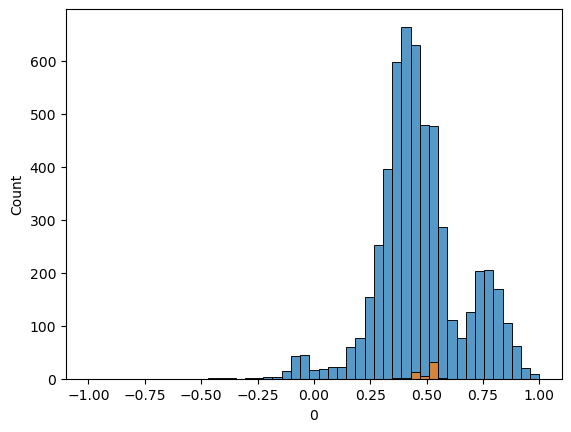

In [72]:
col = 100
element = 0
sns.histplot(train_data[col].loc[:, element], bins=np.linspace(-1, 1))
sns.histplot(col_datasets[col].T.loc[:, element], bins=np.linspace(-1, 1))

## Generate embedding and examine

In [261]:
with open('./../data/validation_datasets/Arthrobacter/keeplength_adk_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

arth_aln_df = pd.concat(lines, axis=1).T

arth_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,-,M,-,N,I,I,L,L,G,P,...,L,D,N,-,-,-,-,-,-,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,M,M,-,G,I,V,M,L,G,A,...,L,L,-,-,-,-,-,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,-,M,-,R,L,I,L,L,G,A,...,L,G,-,-,-,R,-,-,-,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,-,M,-,R,L,L,I,M,G,P,...,L,T,K,-,-,-,-,-,-,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,G,-,-,A,I,L,I,L,G,A,...,L,E,Y,-,L,L,E,K,-,-


In [263]:
# Load model and alphabet
model, alphabet = pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

ESM2(
  (embed_tokens): Embedding(33, 320, padding_idx=1)
  (layers): ModuleList(
    (0-5): 6 x TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=320, out_features=320, bias=True)
        (v_proj): Linear(in_features=320, out_features=320, bias=True)
        (q_proj): Linear(in_features=320, out_features=320, bias=True)
        (out_proj): Linear(in_features=320, out_features=320, bias=True)
        (rot_emb): RotaryEmbedding()
      )
      (self_attn_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=320, out_features=1280, bias=True)
      (fc2): Linear(in_features=1280, out_features=320, bias=True)
      (final_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
  )
  (contact_head): ContactPredictionHead(
    (regression): Linear(in_features=120, out_features=1, bias=True)
    (activation): Sigmoid()
  )
  (emb_layer_norm_after): LayerNorm((320,), eps=1e-05, elementwis

In [264]:
data = []
for index, row in arth_aln_df.iterrows():
    seq = ''.join([s for s in row.values if s != '-'])

    # Clean sequence to ensure valid AAs only
    VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
    clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
    
    if len(seq) == len(clean_seq):
        
        # Batch convert
        data.append((index, clean_seq))
    else:
        print('Uh oh, invalid AA!')
    
    # print(len(protein.sequence), len(seq), protein.get_embedding(layer=12).shape)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [265]:
%%time
# compute representations from sixth layer
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 24min 34s, sys: 34min 50s, total: 59min 25s
Wall time: 4min 32s


In [268]:
# make a df
cls_embedding = pd.DataFrame(index=[l.split('|')[1] for l in labels], data=reps[:, 0, :])

In [269]:
tsne = TSNE(n_components=2, random_state=143, perplexity=50)
embedding_2d = tsne.fit_transform(cls_embedding)

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7f6e284941f0>
Traceback (most recent call last):
  File "/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/site-packages/threadpoolctl.py", line 1008, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/site-packages/threadpoolctl.py", line 1147, in _make_controller_from_path
    lib_controller = controller_class(
  File "/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/site-packages/threadpoolctl.py", line 113, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/ctypes/__init__.py", line 374, in __init__
    self._handle = _dlopen(self._name, mode)
OSError: dlopen() error


In [277]:
plotdf = pd.DataFrame(embedding_2d, index=cls_embedding.index)

In [281]:
plotdf.head()

,0,1
GB_GCA_000016765.1,4.075534,17.701881
GB_GCA_000242235.1,34.500420,24.651428
GB_GCA_000283575.1,9.598133,-14.286525
GB_GCA_000376885.1,-48.594212,-1.535736
GB_GCA_000411155.1,-42.501831,3.956789


In [282]:
plotdf.index.str.contains('tbl')

array([False, False, False, ...,  True,  True,  True])

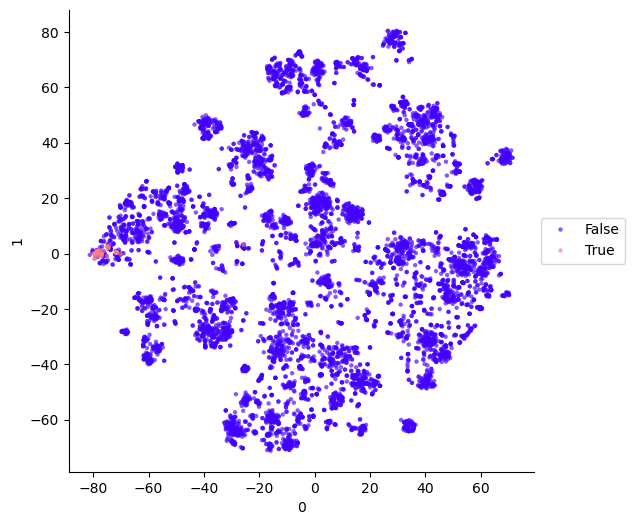

In [284]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=plotdf, x=0, y=1, s=10, hue=plotdf.index.str.contains('tbl'), palette='gnuplot2', 
                linewidth=0, alpha=0.65)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_aspect('equal')
sns.despine()
plt.show()


# Mycobacteria

get accession list from `PRJNA1163726`
prefetch  
`~/tools/sratoolkit.2.11.3-centos_linux64/bin/prefetch --option-file ./../md/accessions.txt`  

Need to modify these scripts to specify an output directory
fasterq-dump  
`~/fiererlab/adenylate_kinase_ogt/scripts/fqd.sh`  
assemble (from `genomes`)  
`~/fiererlab/adenylate_kinase_ogt/scripts/spades.sh ./../md/accessions.txt`

In [383]:
import subprocess
from IPython.display import display, clear_output

In [388]:
# rename files
base = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Mycobacteria/genomes/'
scaffolds = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Mycobacteria/genomes/*_spades/scaffolds.fasta')
for i, sf in enumerate(scaffolds):

    display(i)
    clear_output(wait=True)
    
    genome = sf.split('/')[-2].split('_spades')[0]
    new_name = os.path.join(base, f'{genome}.fasta')
    subprocess.call(['cp', sf, new_name])

    # rename contigs
    with open(new_name, 'r') as handle:
        records  = [r for r in SeqIO.parse(handle, format='fasta')]

    for r in records:
        r.id = f'{r.id}|{genome}'
        r.description = ''

    with open(new_name, 'w') as handle:
        SeqIO.write(records, handle, format='fasta')

19

## Step 1. annotate genomes
From `/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Arthrobacter/genomes`  
```
ls *.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./
cat ./genomes/*_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

In [390]:
myco_md = pd.read_excel('./../data/validation_datasets/Mycobacteria/md/MycoGrowthOptima_IsolateInformation-Detailed_Supplementary_Table1_vFinal_072025.xlsx')

In [398]:
sra_table = pd.read_csv('./../data/validation_datasets/Mycobacteria/md/myco_SraRunTable.csv')
myco_md_full = pd.merge(sra_table[['Sample Name', 'Run']].assign(sample=sra_table['Sample Name'].apply(lambda x: x.replace('NTM', 'NTM-'))),
         myco_md,
         left_on='sample',
         right_on='Isolate ID')


In [399]:
with open('./../data/validation_datasets/Mycobacteria/keeplength_adk_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

myco_aln_df = pd.concat(lines, axis=1).T

myco_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,-,M,-,N,I,I,L,L,G,P,...,L,D,N,-,-,-,-,-,-,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,M,M,-,G,I,V,M,L,G,A,...,L,L,-,-,-,-,-,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,-,M,-,R,L,I,L,L,G,A,...,L,G,-,-,-,R,-,-,-,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,-,M,-,R,L,L,I,M,G,P,...,L,T,K,-,-,-,-,-,-,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,G,-,-,A,I,L,I,L,G,A,...,L,E,Y,-,L,L,E,K,-,-


In [400]:
myco_aln_df = myco_aln_df[~myco_aln_df.index.isin(aln_df.index)]

In [401]:
data = []
# for each protein
for index, row in myco_aln_df.iterrows():
    seq = ''.join([s for s in row.values if s != '-'])

    # Clean sequence to ensure valid AAs only
    VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
    clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
    
    if len(seq) == len(clean_seq):
        # Batch convert
        data.append((index, clean_seq))
    else:
        print('Uh oh, invalid AA!')
        
    # print(len(protein.sequence), len(seq), protein.get_embedding(layer=12).shape)

In [402]:
%%time
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
# per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 7.57 s, sys: 2.77 s, total: 10.3 s
Wall time: 712 ms


In [404]:
col_datasets = {}
# for each column in the alignment
for col in myco_aln_df.columns:
    # get proteins which have a residue (not a gap) at this col
    rows = myco_aln_df[~myco_aln_df[col].eq('-')].index
    col_str = f'{len(rows)} rows available for col {col}'

    # get the rows
    subset = myco_aln_df.loc[rows, :]
    # get which residue this corresponds to in each protein, zero-indexed
    indeces = subset.apply(lambda row: get_residue_loc(row, col=col, base=0), axis=1)

    if len(indeces) > 0:
        # for each protein
        temp_list = []
        for j, (index, item) in enumerate(indeces.items()):
            
            # progress bar
            if j % 100 == 0:
                progress_str = '#' * int((j / len(indeces)) * 20)
                fill_str = '-' * (20-len(progress_str))
                print(col_str + f' |{progress_str}{fill_str}|     ', end='\r')
    
            # get the embedding for that site in that protein
            ploc_in_reps = labels.index(index)
            tensor = pd.Series(data=reps.detach()[ploc_in_reps, item+1, :].numpy(), name=index)
            temp_list.append(tensor)
            
        col_datasets[col] = pd.concat(temp_list, axis=1)

## ensemble predictions from main model for mycobacteria species

here we go!!!!

In [406]:
with open('./../data/proclam/esm2_t6_8M_UR50D/models.pickle', 'rb') as handle:
    models = pickle.load(handle)

In [410]:
myco_md_full.columns

Index(['Sample Name', 'Run', 'sample', 'Isolate ID',
       'Closest Taxonomic Neighbor (Projected Species)', 'Genome Size',
       'Source Environment', 'Experimental Timepoint ', 'pH Optimum',
       'Temperature Optimum (℃)', 'Optimal pH Range (50%)',
       'Optimal Temperature Range (50%)', 'Model Fit (R-squared)',
       'Pathogenicity', 'Site of Pathology',
       'Citation (for reported pathogenicity)'],
      dtype='object')

In [411]:
y = myco_md_full.set_index('Run')['Temperature Optimum (℃)']

In [412]:
high_frac_sites = (~myco_aln_df.eq('-')).sum() / myco_aln_df.shape[0]
high_frac_sites[high_frac_sites < 0.25]

0      0.05
2      0.00
129    0.00
130    0.00
131    0.00
132    0.00
133    0.00
134    0.00
135    0.00
136    0.00
137    0.00
138    0.00
139    0.00
140    0.00
141    0.00
142    0.00
143    0.00
144    0.00
145    0.00
146    0.00
147    0.00
148    0.00
149    0.00
150    0.00
151    0.00
152    0.00
153    0.00
154    0.00
155    0.00
156    0.00
157    0.00
158    0.00
159    0.00
160    0.00
161    0.00
190    0.00
191    0.05
192    0.05
195    0.10
196    0.00
197    0.00
198    0.00
200    0.00
201    0.00
202    0.00
203    0.00
204    0.00
222    0.00
225    0.00
229    0.00
230    0.00
231    0.00
233    0.00
234    0.00
235    0.00
236    0.00
dtype: float64

In [417]:
pd.concat(predictions, axis=1)

,0,191,192,195
NODE_34_length_62981_cov_9.114392|SRR32180453_20|SRR32180453_hmmsearch.tbl|XXXtemp=XXX|bitscore=183.9,30.181641,NaN,NaN,NaN
NODE_39_length_44013_cov_18.787244|SRR32180455_10|SRR32180455_hmmsearch.tbl|XXXtemp=XXX|bitscore=185.3,NaN,22.583008,-53.542252,NaN
NODE_9_length_205973_cov_23.464231|SRR32180444_145|SRR32180444_hmmsearch.tbl|XXXtemp=XXX|bitscore=182.5,NaN,NaN,NaN,45.480469
NODE_9_length_124674_cov_7.321638|SRR32180454_98|SRR32180454_hmmsearch.tbl|XXXtemp=XXX|bitscore=183.7,NaN,NaN,NaN,37.068359


In [455]:
plotdf

,predicted,Temperature Optimum (℃)
SRR32180453,36.593792,31.3
SRR32180441,30.962173,31.6
SRR32180442,40.304939,38.2
SRR32180443,32.160496,37.4
SRR32180444,39.461082,32.8
SRR32180445,36.940029,32.0
SRR32180446,33.072800,37.9
SRR32180447,38.569557,33.4
SRR32180448,39.451515,38.6
SRR32180449,31.372267,26.9


Text(0.5, 1.0, 'Mycobacteria')

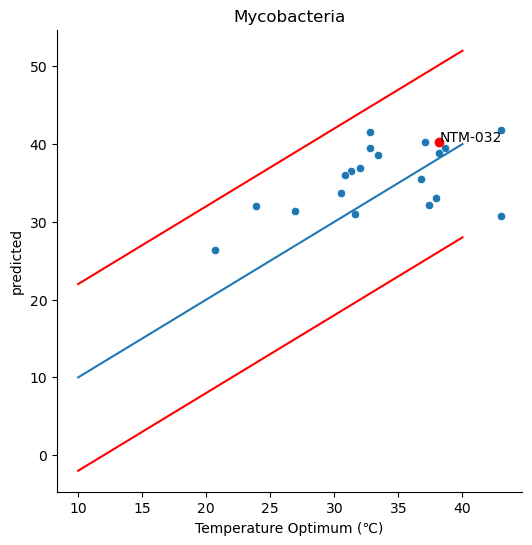

In [463]:
predictions = []
for col in list(col_datasets.keys()):
    if not col in [191, 192]:
        predictions.append(pd.Series(index=col_datasets[col].T.index, data=models[col].predict(col_datasets[col].T), name=col))

y_pred = pd.concat(predictions, axis=1) 
y_pred.index = [s.split('|')[2].split('_hmmsea')[0] for s in y_pred.index]
y_mean = y_pred.mean(1).rename('predicted')
plotdf = pd.merge(y_mean, 
         y, 
         left_index=True, right_index=True)

fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=plotdf, y='predicted', x='Temperature Optimum (℃)')

for index, row in plotdf.iterrows():
    if '032' in myco_md_full.set_index('Run')['sample'].loc[index]:
        ax.annotate( myco_md_full.set_index('Run')['sample'].loc[index], (row['Temperature Optimum (℃)'], row['predicted']))
        plt.scatter(y=row['predicted'], x=row['Temperature Optimum (℃)'], c='r')

_x, _y = 10, 40
rmse = 12
plt.plot((_x, _y), (_x-rmse, _y-rmse), color='r')
plt.plot((_x, _y), (_x+rmse, _y+rmse), color='r')
plt.plot((_x, _y), (_x, _y))

sns.despine()

ax.set_title('Mycobacteria')

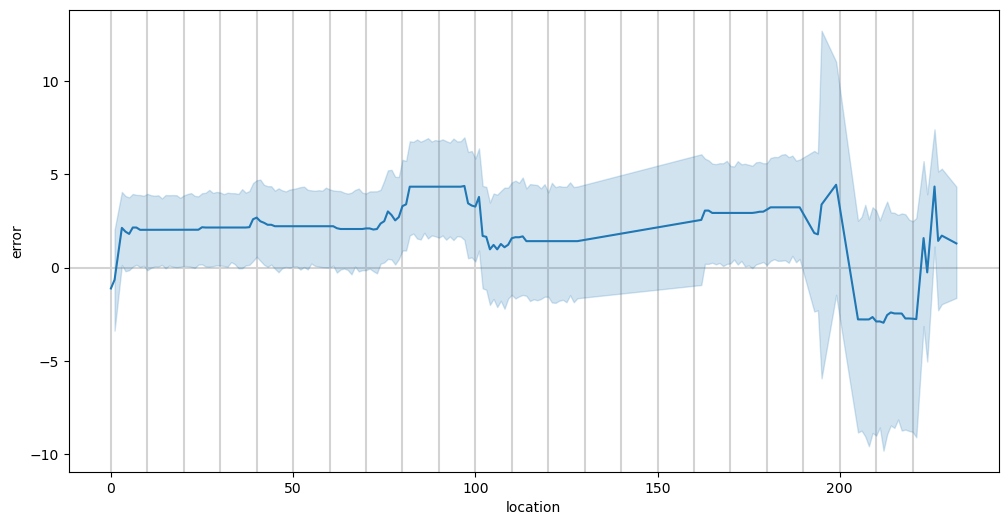

In [433]:
plotdf = y_pred.apply(lambda x: x - y, axis=0).stack().reset_index().rename(columns={'level_0':'genome', 'level_1':'location', 0:'error'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plotdf, 
             x='location', 
             y='error', 
             # hue='genome', 
             legend=False)

for i in range(0, 230, 10):
    ax.axvline(i, color='lightgray', zorder=0)
    
ax.axhline(0, color='lightgray', zorder=0)

In [434]:
plotdf.groupby('location').agg({'error':'mean'}).sort_values('error')

,error
location,
212,-2.953667
210,-2.885814
211,-2.883599
206,-2.778162
207,-2.778162
...,...
88,4.330684
92,4.330684
226,4.338893


In [436]:
counts = myco_aln_df.apply(lambda col: col.value_counts(), axis=0).fillna(0)

counts = counts.divide(counts.sum()).T
counts.head()

,-,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,Y
0,0.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.05,0.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.0


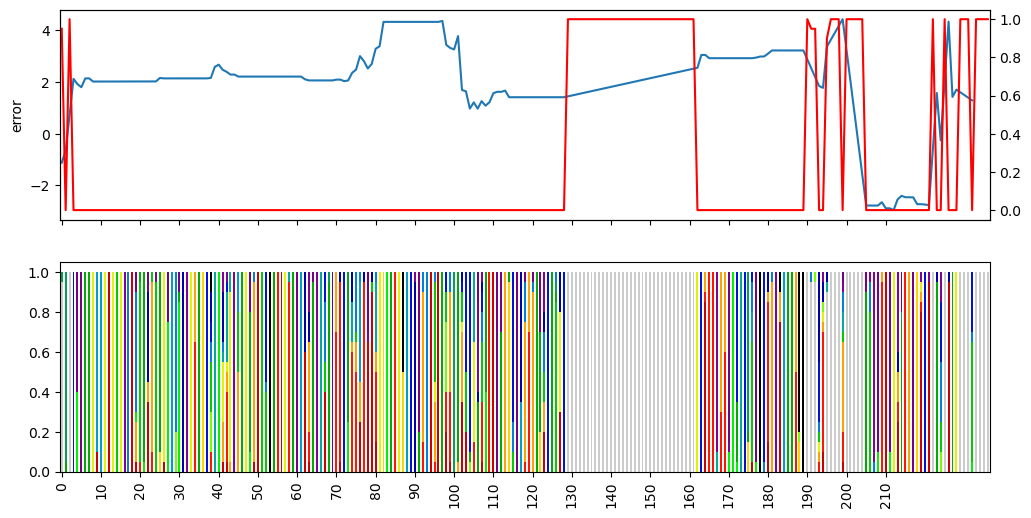

In [437]:
# number of gaps per site
fig= plt.figure(figsize=(12,6))
ax = fig.add_subplot(2,1,1)
sns.lineplot(plotdf.groupby('location').agg({'error':'mean'})['error'], 
             ax=ax)

rax = ax.twinx()
sns.lineplot(myco_aln_df.eq('-').sum() / myco_aln_df.shape[0], ax=rax, color='r')

rax.set_xlim(10, 210)

ax = fig.add_subplot(2,1,2, sharex=ax)
counts.plot(kind='bar', stacked=True, legend=False, ax=ax, cmap='nipy_spectral_r')
ax.set_xticks(range(0,220,10))

In [324]:
col = 0
contributions = []
for item in range(30):
    clear_output(wait=True)
    try:
        thresh = y.loc[col_datasets[col].T.iloc[item, :].name.split('|')[1].split('_hmm')[0]] + 1
        feature_means = train_data[col].loc[[s  for s in train_data[col].index if float(s.split('|')[3].split('temp=')[-1])  < thresh], :].mean()
        coefs = pd.Series(models[col].coef_, index=train_data[col].columns)
        
        # Expected prediction at average values
        expected_pred = feature_means @ coefs + models[col].intercept_
        
        # Prediction for this input
        actual_pred = col_datasets[col].T.iloc[item, :] @ coefs + models[col].intercept_
        
        contribution_df = (col_datasets[col].T.iloc[item, :] - feature_means) * coefs
        
        # fig, ax = plt.subplots(figsize=(12, 4))
        # contribution_df.plot.bar()
        
        contributions.append(contribution_df)
        
        print('diff', contribution_df.sum())
        
        print('expected', expected_pred)
        
        print('actual', actual_pred)
    except KeyError:
        ''

diff 14.460205
expected 12.580078
actual 27.03711


<Axes: >

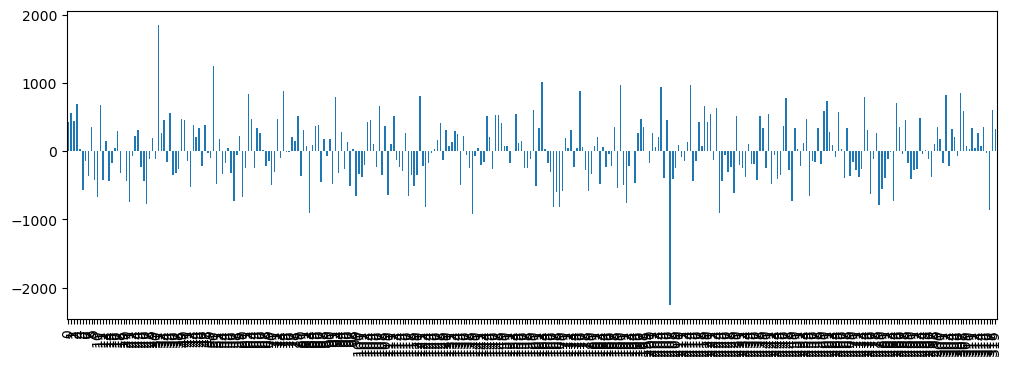

In [325]:
fig, ax = plt.subplots(figsize=(12, 4))
pd.concat(contributions, axis=1).mean(1)
contributions[-1].plot.bar()


## Examining embeddings

In [440]:
with open('./../data/validation_datasets/Mycobacteria/keeplength_adk_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

myco_aln_df = pd.concat(lines, axis=1).T

myco_aln_df.head()

,0,1,2,3,4,5,6,7,8,9,...,227,228,229,230,231,232,233,234,235,236
CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3,-,M,-,N,I,I,L,L,G,P,...,L,D,N,-,-,-,-,-,-,-
JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2,M,M,-,G,I,V,M,L,G,A,...,L,L,-,-,-,-,-,-,-,-
AP012044.1_910|GB_GCA_000283575.1|adk|temp=30.0|bitscore=168.7,-,M,-,R,L,I,L,L,G,A,...,L,G,-,-,-,R,-,-,-,-
AQXR01000011.1_67|GB_GCA_000376885.1|adk|temp=37.0|bitscore=178.2,-,M,-,R,L,L,I,M,G,P,...,L,T,K,-,-,-,-,-,-,-
KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5,G,-,-,A,I,L,I,L,G,A,...,L,E,Y,-,L,L,E,K,-,-


In [441]:
data = []
# for each protein
for index, row in myco_aln_df.iterrows():
    seq = ''.join([s for s in row.values if s != '-'])

    # Clean sequence to ensure valid AAs only
    VALID_AAS = set("ACDEFGHIKLMNPQRSTVWY")
    clean_seq = ''.join([aa for aa in seq if aa in VALID_AAS])
    
    if len(seq) == len(clean_seq):
        # Batch convert
        data.append((index, clean_seq))
    else:
        print('Uh oh, invalid AA!')
        
    # print(len(protein.sequence), len(seq), protein.get_embedding(layer=12).shape)

Uh oh, invalid AA!
Uh oh, invalid AA!
Uh oh, invalid AA!


In [442]:
%%time
# compute representations from sixth layer
labels, strs, toks = batch_converter(data)
    
with torch.no_grad():
    out = model(toks, repr_layers=[6])
    reps = out["representations"][6]

# Get per-residue embedding (remove CLS, keep real residues)
per_residue_embed = reps[0, 1:len(clean_seq)+1]  # shape: (L, embed_dim)

CPU times: user 37min 14s, sys: 28min 10s, total: 1h 5min 25s
Wall time: 5min 25s


In [443]:
# make a df
cls_embedding = pd.DataFrame(index=[l.split('|')[1] for l in labels], data=reps[:, 0, :])

In [444]:
tsne = TSNE(n_components=2, random_state=143, perplexity=50)
embedding_2d = tsne.fit_transform(cls_embedding)

In [445]:
plotdf = pd.DataFrame(embedding_2d, index=cls_embedding.index)

In [446]:
plotdf.head()

,0,1
GB_GCA_000016765.1,9.403959,22.883965
GB_GCA_000242235.1,35.536953,25.448410
GB_GCA_000283575.1,2.528726,-11.051918
GB_GCA_000376885.1,-48.845066,-3.020257
GB_GCA_000411155.1,-42.683128,15.264618


In [447]:
plotdf.index.str.contains('tbl')

array([False, False, False, ..., False, False, False])

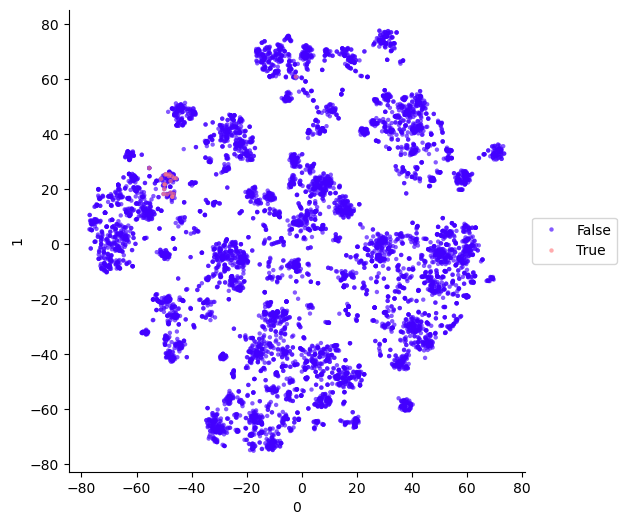

In [450]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=plotdf, x=0, y=1, s=10, hue=plotdf.index.str.contains('SRR'), palette='gnuplot2', 
                linewidth=0, alpha=0.65)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_aspect('equal')
sns.despine()
plt.show()


In [449]:
plotdf

,0,1
GB_GCA_000016765.1,9.403959,22.883965
GB_GCA_000242235.1,35.536953,25.448410
GB_GCA_000283575.1,2.528726,-11.051918
GB_GCA_000376885.1,-48.845066,-3.020257
GB_GCA_000411155.1,-42.683128,15.264618
...,...,...
SRR32180456_94,-48.928677,18.127337
SRR32180457_58,-47.065647,24.661835
SRR32180458_18,-50.175716,18.259048
SRR32180459_335,-49.110924,25.515057
